In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import os
import joblib

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

# Hyperparameter tuning for Random Forest using RandomizedSearchCV
rf_model = RandomForestRegressor()

# Set the hyperparameters grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
#     'bootstrap': [True, False]
}

# Randomized Search CV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, 
                                   n_iter=50, scoring='neg_mean_squared_error', 
                                   cv=3, verbose=1, random_state=42, n_jobs=-1)

random_search.fit(X_normal, Y_normal)

# Get the best hyperparameters
best_params = random_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Now using the best hyperparameters for the model

# Create a folder to save models if it doesn't exist
model_dir = "RandomForest_best_trial"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# DataFrame to store results
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE'])

# Run the model 100 times with different parameters and splits
for run in range(1, 101):
    print(f'Run {run}')
    
    # Split the data randomly each time
    Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=run)

    # Create the RandomForest model with the best hyperparameters
    rf_model = RandomForestRegressor(**best_params)

    # Train the model
    rf_model.fit(Xtrain, ytrain)

    # Saving the model
    model_filename = os.path.join(model_dir, f'rf_model_run_{run}.joblib')
    joblib.dump(rf_model, model_filename)

    # Evaluate the model
    ytrain_pred = rf_model.predict(Xtrain)
    ytest_pred = rf_model.predict(Xtest)

    # Calculate metrics
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)

    # Append results to DataFrame using concat
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Run': run,
        'Test R2': test_r2,
        'Train R2': train_r2,
        'RMSE': rmse,
        'MAE': mae
    }])], ignore_index=True)

    # Print the results for this run
    print(f'Run {run}: Test R² = {test_r2}, Train R² = {train_r2}, RMSE = {rmse}, MAE = {mae}')

# Save the results to an Excel file
results_df.to_excel('RandomForest_best_trial_results.xlsx', index=False)

print("Results and models saved successfully.")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best hyperparameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Run 1
Run 1: Test R² = 0.7255819212871512, Train R² = 0.9199257037992568, RMSE = 0.5249326652702049, MAE = 0.38530541412893937
Run 2
Run 2: Test R² = 0.7053105760996017, Train R² = 0.9213657840891789, RMSE = 0.5354942069722406, MAE = 0.3903162707285045
Run 3
Run 3: Test R² = 0.7253105024591702, Train R² = 0.9194847874943096, RMSE = 0.5228900505629033, MAE = 0.3863032447747653
Run 4
Run 4: Test R² = 0.7424423477693496, Train R² = 0.9187466201157062, RMSE = 0.4890060176052947, MAE = 0.352797355141648
Run 5
Run 5: Test R² = 0.7471961667823994, Train R² = 0.9181874923519101, RMSE = 0.472609867268186, MAE = 0.35360327750944176
Run 6
Run 6: Test R² = 0.7315020048444298, Train R² = 0.9183105876255933, RMSE = 0.5037265029455728, MAE = 0.3735439040256678
Run 7
Run 7: Test R² = 0.7355277087862138, Train R² = 0.9189801552416722

Run 64: Test R² = 0.7599629313046907, Train R² = 0.9179793774662766, RMSE = 0.4903122388235109, MAE = 0.34913255082904826
Run 65
Run 65: Test R² = 0.7606069391172434, Train R² = 0.9161091519127, RMSE = 0.507839686563066, MAE = 0.3723110735436886
Run 66
Run 66: Test R² = 0.7326169599629404, Train R² = 0.9186723904048159, RMSE = 0.5235183355857292, MAE = 0.38688912887391735
Run 67
Run 67: Test R² = 0.7458244824798883, Train R² = 0.9199093919157395, RMSE = 0.4953272622775131, MAE = 0.36549574872236684
Run 68
Run 68: Test R² = 0.7359559371369625, Train R² = 0.9198457901108377, RMSE = 0.5106193520013346, MAE = 0.3768624185851025
Run 69
Run 69: Test R² = 0.7036385598377586, Train R² = 0.9207013282437634, RMSE = 0.5404133066021524, MAE = 0.3845394266576958
Run 70
Run 70: Test R² = 0.731063391495927, Train R² = 0.9194210997403623, RMSE = 0.539627461811551, MAE = 0.38685888906305493
Run 71
Run 71: Test R² = 0.7228879621085993, Train R² = 0.9175314532432046, RMSE = 0.5526564307209898, MAE = 0.39

In [2]:
# time 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import os
import joblib
import time  # 导入时间模块

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
Y = df['fc (MPa)'].values

# Normalize the data
x_mean, x_std = X.mean(0), X.std(0)
X_normal = (X - x_mean) / x_std
y_mean, y_std = Y.mean(), Y.std()
Y_normal = (Y - y_mean) / y_std

# Hyperparameter tuning
rf_model = RandomForestRegressor()
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, 
                                   n_iter=50, scoring='neg_mean_squared_error', 
                                   cv=3, verbose=1, random_state=42, n_jobs=-1)
random_search.fit(X_normal, Y_normal)
best_params = random_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Model saving setup
model_dir = "RandomForest_best_trial"
if not os.path.exists(model_dir): os.makedirs(model_dir)

# DataFrame to store results
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE', 'Execution_Time_s'])

# Run 100 times with timer
for run in range(1, 101):
    # 记录开始时间
    start_time = time.time()
    
    Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=run)
    rf_model = RandomForestRegressor(**best_params)
    rf_model.fit(Xtrain, ytrain)
    
    # Evaluate
    ytrain_pred = rf_model.predict(Xtrain)
    ytest_pred = rf_model.predict(Xtest)
    
    # 记录结束时间
    end_time = time.time()
    elapsed = end_time - start_time
    
    # Calculate metrics
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)
    
    # Append results
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Run': run, 'Test R2': test_r2, 'Train R2': train_r2, 
        'RMSE': rmse, 'MAE': mae, 'Execution_Time_s': elapsed
    }])], ignore_index=True)
    
    # 保存模型
    joblib.dump(rf_model, os.path.join(model_dir, f'rf_model_run_{run}.joblib'))
    
    print(f'Run {run}: Time={elapsed:.4f}s, Test R²={test_r2:.4f}')

# Final output
results_df.to_excel('RandomForest_best_trial_results.xlsx', index=False)
print(f"所有运行结束。平均单次运行时间: {results_df['Execution_Time_s'].mean():.4f} 秒")
print("Results and models saved successfully.")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Run 1: Time=4.2460s, Test R²=0.7234
Run 2: Time=4.2583s, Test R²=0.6986
Run 3: Time=4.2566s, Test R²=0.7187
Run 4: Time=4.3930s, Test R²=0.7397
Run 5: Time=4.4982s, Test R²=0.7426
Run 6: Time=4.6213s, Test R²=0.7220
Run 7: Time=4.4005s, Test R²=0.7282
Run 8: Time=4.3411s, Test R²=0.7275
Run 9: Time=4.2715s, Test R²=0.6852
Run 10: Time=4.2726s, Test R²=0.7377
Run 11: Time=4.4206s, Test R²=0.7273
Run 12: Time=4.4936s, Test R²=0.7353
Run 13: Time=4.6187s, Test R²=0.7580
Run 14: Time=4.3265s, Test R²=0.6880
Run 15: Time=4.2650s, Test R²=0.6803
Run 16: Time=4.2685s, Test R²=0.7628
Run 17: Time=4.6528s, Test R²=0.7281
Run 18: Time=3.9766s, Test R²=0.7063
Run 19: Time=3.1833s, Test R²=0.7179
Run 20: Time=3.0944s, Test R²=0.7700
Run 21: Time=3.0772s, Test R²=0.7231
Run 22: Time=3.0926s, Test R²=0.7278
Run 23: Time=3.0846s, Tes

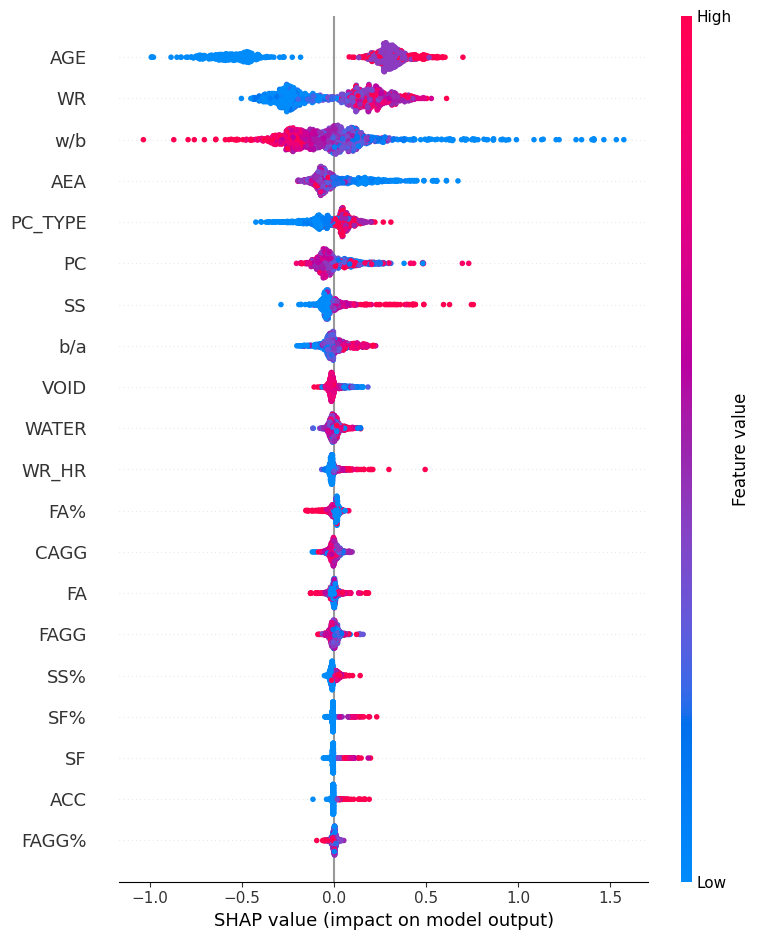

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # Import the RandomForestRegressor
import matplotlib.pyplot as plt

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Define features
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']  # Define features
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

# Set Random Forest hyperparameters
n_estimators = 500  # Number of trees
max_depth = 20  # Maximum depth of the trees

# Create the Random Forest model
random_forest_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, bootstrap=True)

# Train the model using the residual values as the target
random_forest_model.fit(Xtrain, ytrain)  # Use ytrain here instead of ytrain_residual

# Perform SHAP analysis using TreeExplainer for Random Forest
explainer = shap.TreeExplainer(random_forest_model)  # Use TreeExplainer for tree-based models
shap_values = explainer.shap_values(Xtest)  # Calculate SHAP values for the test data



In [ ]:
# Optional: Visualize SHAP values
shap.initjs()  # Initialize JS visualization
shap.summary_plot(shap_values, Xtest_df, feature_names=features)  # Create summary plot

X has feature names, but RandomForestRegressor was fitted without feature names


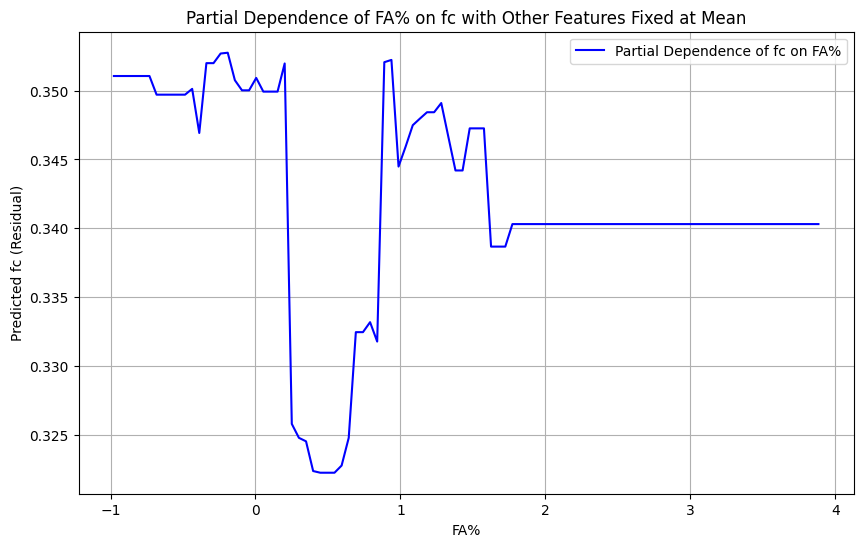

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
Y = df['fc (MPa)'].values  # Ensure this column exists in your DataFrame

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=42)

# Set Random Forest hyperparameters
n_estimators = 500  # Number of trees
max_depth = 20  # Maximum depth of the trees

# Create the Random Forest model
random_forest_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, bootstrap=True)

# Train the model using the residual values as the target
random_forest_model.fit(Xtrain, ytrain)

# Create a new DataFrame for the partial dependence plot
mean_values = X_normal.mean(axis=0)
fa_percent_range = np.linspace(X_normal[:, features.index('FA%')].min(), X_normal[:, features.index('FA%')].max(), 100)

# Prepare data for predictions
pdp_data = pd.DataFrame(np.tile(mean_values, (fa_percent_range.size, 1)), columns=features)
pdp_data['FA%'] = fa_percent_range  # Vary FA%

# Make predictions
pdp_predictions = random_forest_model.predict(pdp_data)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(fa_percent_range, pdp_predictions, label='Partial Dependence of fc on FA%', color='blue')
plt.title('Partial Dependence of FA% on fc with Other Features Fixed at Mean')
plt.xlabel('FA%')
plt.ylabel('Predicted fc (Residual)')
# plt.axhline(0, color='red', linestyle='--', label='Zero Line')  # Add a zero line for reference
plt.legend()
plt.grid()
plt.show()
